# 02 — Análisis LLM de negociaciones — LockBit

Clasifica los 4,423 mensajes de negociación con `qwen2.5:14b` en fases  
del proceso de extorsión y perfila el estilo de cada operador.

**Diferencia clave con ContiLeaks/BlackBasta**: aquí los chats son entre  
_operadores LockBit_ (extorsionadores) y _víctimas_ (empresas comprometidas),  
no comunicación interna del grupo.

Produce:
- `data/processed/chats_classified.parquet`
- `data/processed/operator_profiles.json`

## 0. Setup

In [1]:
# Módulos estándar de Python
import json   # Para leer/escribir datos en formato JSON (listas y diccionarios estructurados)
import time   # Para medir cuánto tiempo tarda el proceso de clasificación

# Librerías de análisis y visualización
import pandas as pd          # Para trabajar con tablas de datos (DataFrames)
import numpy as np           # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para crear gráficas

# "ollama" es la librería que nos permite usar modelos de lenguaje (LLMs) localmente.
# Ollama es un servidor que corre en tu máquina y permite usar modelos como Qwen, LLaMA, etc.
# sin necesidad de conexión a internet ni de pagar por una API externa.
import ollama

# "Path" para manejar rutas de archivos de forma cómoda
from pathlib import Path

# "tqdm" muestra una barra de progreso mientras procesamos muchos elementos en un bucle.
# La variante "tqdm.auto" se adapta automáticamente al entorno (notebook o terminal).
from tqdm.auto import tqdm

# Definimos todas las rutas de archivos del notebook
PROCESSED        = Path('data/processed')
CHATS_IN         = PROCESSED / 'chats.parquet'        # Chats de negociación (de notebook 00)
USERS_IN         = PROCESSED / 'users.parquet'        # Operadores y afiliados
CLIENTS_IN       = PROCESSED / 'clients.parquet'      # Víctimas
CHATS_OUT        = PROCESSED / 'chats_classified.parquet'   # Resultado con fases etiquetadas
PROFILES_OUT     = PROCESSED / 'operator_profiles.json'     # Perfiles de cada operador
CHECKPOINT_PATH  = PROCESSED / 'chats_checkpoint.parquet'   # Guardado intermedio por si se interrumpe

# Especificamos qué modelo de lenguaje usaremos para la clasificación.
# qwen2.5:14b es un modelo con 14 mil millones de parámetros, suficientemente potente
# para entender y clasificar mensajes de negociación de ransomware.
MODEL = 'qwen2.5:14b'

# Verificamos que los archivos de entrada existen antes de continuar
for f in [CHATS_IN, USERS_IN, CLIENTS_IN]:
    assert f.exists(), f'Falta {f} — ejecuta notebook 00'

# Cargamos los datos de entrada
chats   = pd.read_parquet(CHATS_IN)
users   = pd.read_parquet(USERS_IN)
clients = pd.read_parquet(CLIENTS_IN)

# Filtramos para quedarnos solo con mensajes de texto (excluimos archivos adjuntos).
# is_file == 0 → el mensaje es texto, no un archivo
chats_text = chats[chats.is_file == 0].copy()

# Excluimos también los mensajes que están vacíos o tienen menos de 4 caracteres.
# .notna() → el campo no es nulo
# .str.strip() → elimina espacios al principio y al final
# .str.len() > 3 → el texto tiene más de 3 caracteres útiles
chats_text = chats_text[chats_text.content.notna() & (chats_text.content.str.strip().str.len() > 3)]

print(f'Mensajes de texto: {len(chats_text):,}')
print(f'Adjuntos excluidos: {(chats.is_file==1).sum()}')
print('Setup OK')

Mensajes de texto: 3,977
Adjuntos excluidos: 188
Setup OK


/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Clasificación de fases de negociación

In [2]:
# Definimos las 6 fases posibles del proceso de extorsión de ransomware.
# El modelo de lenguaje clasificará cada mensaje en exactamente una de estas fases.
# Usamos un conjunto (set) porque solo necesitamos saber si la respuesta es válida,
# y los conjuntos son más rápidos que las listas para eso (operación 'in').
PHASES = {'opening', 'technical_proof', 'price_negotiation',
          'payment_instructions', 'closing', 'unknown'}

# Este es el "system prompt": las instrucciones que le damos al LLM para explicarle
# quién es y qué tarea debe realizar. Es el equivalente a un briefing profesional.
# Un buen system prompt es crucial para obtener respuestas precisas y consistentes.
# Lo escribimos en inglés porque los LLMs entienden mejor las instrucciones en inglés.
SYSTEM_PROMPT = """You are a threat intelligence analyst studying LockBit ransomware negotiation transcripts.
These are chats between LockBit operators (extortionists) and their victims (compromised companies).
Classify each message into exactly one phase of the extortion process:

- opening: first contact, welcome message, initial instructions for the victim
- technical_proof: requests for test files, proof of decryption, technical questions about encryption
- price_negotiation: ransom amount, discount requests, counter-offers, urgency pressure
- payment_instructions: bitcoin address, payment confirmation, wallet instructions
- closing: decryption key delivery, post-payment, farewell, threats if unpaid
- unknown: off-topic, unintelligible, empty, or cannot be classified

Reply with ONLY the phase name, nothing else."""


def classify_message(text: str, sender: str) -> str:
    """
    Clasifica un mensaje de negociación en una de las 6 fases del proceso de extorsión,
    usando un modelo de lenguaje (LLM) local vía Ollama.

    La idea central es: en lugar de escribir reglas manualmente para detectar si un mensaje
    es una instrucción de pago o una negociación de precio, dejamos que el LLM lo entienda
    de forma natural, como lo haría un analista humano.

    Parámetros:
        text (str): El contenido del mensaje a clasificar
        sender (str): Quién lo envió ('operator' o 'victim')

    Devuelve:
        str: El nombre de la fase detectada (uno de los valores de PHASES)
    """
    # Si el mensaje es muy corto (menos de 4 caracteres), no hay suficiente información
    if len(str(text).strip()) < 4:
        return 'unknown'

    try:
        # ollama.chat() envía una conversación al modelo local y devuelve su respuesta.
        # Es similar a chatear con ChatGPT pero todo ocurre en tu máquina.
        resp = ollama.chat(
            model=MODEL,
            messages=[
                # El primer mensaje es el "system prompt": instrucciones para el modelo
                {'role': 'system', 'content': SYSTEM_PROMPT},
                # El segundo mensaje es el "user prompt": el mensaje a clasificar
                # Limitamos a 400 caracteres para mantener el coste bajo y la velocidad alta
                {'role': 'user', 'content': f'Sender: {sender}\nMessage: {str(text)[:400]}'}
            ],
            # temperature=0 hace al modelo determinista: siempre dará la misma respuesta
            # para el mismo input, lo que es importante para reproducibilidad
            # num_predict=10 limita la respuesta a 10 tokens (solo necesitamos la fase)
            options={'temperature': 0, 'num_predict': 10}
        )
        # Limpiamos la respuesta: la convertimos a minúsculas, tomamos la primera palabra
        # y quitamos puntuación final (el modelo a veces añade puntos o comas)
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:;')

        # Verificamos que la respuesta es una fase válida; si no, devolvemos 'unknown'
        return raw if raw in PHASES else 'unknown'
    except Exception:
        # Si hay cualquier error (modelo no disponible, timeout, etc.), devolvemos 'unknown'
        return 'unknown'


# Probamos la función con 4 mensajes de ejemplo para verificar que funciona correctamente
print('Test de clasificación:')
tests = [
    ('You can attach a few files for test decryption', 'operator'),
    ('how much decrypt file', 'victim'),
    ('4000$\nwe accept bitcoin only', 'operator'),
    ('bc1qatkg42cxnv5vcxgz4wegkv2u6va9fztdkf6gwj', 'operator'),
]
for msg, sender in tests:
    phase = classify_message(msg, sender)
    # Mostramos el remitente, el comienzo del mensaje y la fase detectada
    print(f'  [{sender:8s}] "{msg[:50]}" → {phase}')

Test de clasificación:


  [operator] "You can attach a few files for test decryption" → technical_proof


  [victim  ] "how much decrypt file" → price_negotiation
  [operator] "4000$
we accept bitcoin only" → price_negotiation


  [operator] "bc1qatkg42cxnv5vcxgz4wegkv2u6va9fztdkf6gwj" → payment_instructions


In [3]:
# Sistema de checkpoint: recuperamos el progreso si la clasificación fue interrumpida.
# Clasificar ~4000 mensajes con un LLM local tarda varios minutos. Si se interrumpe
# (por un error, por apagar el ordenador, etc.), el checkpoint nos permite retomar
# desde donde lo dejamos en lugar de empezar de cero.
if CHECKPOINT_PATH.exists():
    # Si existe el archivo de checkpoint, cargamos los mensajes ya clasificados
    done = pd.read_parquet(CHECKPOINT_PATH)
    # done_ids es el conjunto de índices de los mensajes que ya están clasificados
    done_ids = set(done.index)
    print(f'Checkpoint: {len(done):,} mensajes ya clasificados')
else:
    # Si no hay checkpoint, empezamos de cero
    done = pd.DataFrame()
    done_ids = set()
    print('Comenzando desde cero')

# 'todo' contiene solo los mensajes que AÚN NO han sido clasificados.
# ~chats_text.index.isin(done_ids) significa "cuyo índice NO está en done_ids"
# El símbolo ~ en pandas invierte los True/False (NOT lógico)
todo = chats_text[~chats_text.index.isin(done_ids)].copy()
print(f'Pendientes: {len(todo):,}')

Comenzando desde cero
Pendientes: 3,977


In [4]:
# Definimos cada cuántos mensajes guardamos un checkpoint de seguridad.
# Cada 50 mensajes guardamos el progreso al disco por si se interrumpe el proceso.
CHECKPOINT_EVERY = 50

# Lista donde iremos acumulando los resultados (índice del mensaje + fase detectada)
results = []

# Registramos el tiempo de inicio para calcular cuánto ha tardado el proceso al final
t0 = time.time()

# Bucle principal de clasificación: procesamos cada mensaje pendiente uno a uno.
# tqdm() envuelve el iterador y muestra una barra de progreso en tiempo real.
# .iterrows() recorre el DataFrame fila a fila, devolviendo (índice, fila) en cada iteración.
# 'i' es el contador (0, 1, 2, ...) e 'idx' es el índice real del mensaje en el DataFrame.
for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
    # Determinamos quién envió el mensaje basándonos en el campo 'flag'
    sender = 'operator' if row['flag'] == 1 else 'victim'

    # Enviamos el mensaje al LLM para que lo clasifique y guardamos el resultado
    phase = classify_message(row['content'], sender)

    # Acumulamos el resultado: guardamos el índice y la fase detectada
    results.append({'idx': idx, 'phase': phase})

    # Cada CHECKPOINT_EVERY mensajes, guardamos el progreso en disco.
    # (i + 1) % CHECKPOINT_EVERY == 0 significa "cuando i+1 es múltiplo de 50"
    if (i + 1) % CHECKPOINT_EVERY == 0:
        # Convertimos la lista de resultados a DataFrame y ponemos 'idx' como índice
        chunk = pd.DataFrame(results).set_index('idx')
        # Combinamos los mensajes ya hechos (done) con los nuevos de este chunk
        # assign(phase=chunk['phase']) añade la columna 'phase' al DataFrame de mensajes
        partial = pd.concat([done,
                             chats_text.loc[chunk.index].assign(phase=chunk['phase'])])
        # Guardamos el checkpoint en disco
        partial.to_parquet(CHECKPOINT_PATH)

# Calculamos el tiempo total empleado en la clasificación
elapsed = time.time() - t0
print(f'\nCompletado en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

# Construimos el DataFrame final con todos los mensajes clasificados
new_df = pd.DataFrame(results).set_index('idx')
chats_new = chats_text.loc[new_df.index].copy()
# Asignamos las fases detectadas como una nueva columna en el DataFrame
chats_new['phase'] = new_df['phase'].values

# Combinamos los mensajes del checkpoint anterior (si había) con los nuevos
# y los ordenamos cronológicamente por fecha de creación
classified = pd.concat([done, chats_new]).sort_values('created_at').reset_index(drop=True)
print(f'Total clasificados: {len(classified):,}')

Clasificando:   0%|          | 0/3977 [00:00<?, ?it/s]

Clasificando:   0%|          | 1/3977 [00:00<13:45,  4.82it/s]

Clasificando:   0%|          | 2/3977 [00:00<13:01,  5.09it/s]

Clasificando:   0%|          | 3/3977 [00:00<12:47,  5.18it/s]

Clasificando:   0%|          | 4/3977 [00:00<11:13,  5.90it/s]

...

Clasificando: 100%|█████████▉| 3975/3977 [09:45<00:00,  5.59it/s]

Clasificando: 100%|█████████▉| 3976/3977 [09:45<00:00,  6.08it/s]

Clasificando: 100%|██████████| 3977/3977 [09:45<00:00,  6.38it/s]

Clasificando: 100%|██████████| 3977/3977 [09:45<00:00,  6.79it/s]


Completado en 9.8 min (0.1 s/msg)
Total clasificados: 3,977


## 2. Análisis de resultados

In [5]:
# Definimos el orden en que queremos mostrar las fases (sigue la lógica del proceso de extorsión)
# y los colores que usaremos para cada fase en las gráficas.
phase_order = ['opening', 'technical_proof', 'price_negotiation',
               'payment_instructions', 'closing', 'unknown']
phase_colors = {
    'opening': '#3498db',           # Azul: apertura del contacto
    'technical_proof': '#2ecc71',   # Verde: pruebas técnicas
    'price_negotiation': '#e74c3c', # Rojo: negociación del precio
    'payment_instructions': '#f39c12',  # Naranja: instrucciones de pago
    'closing': '#9b59b6',           # Morado: cierre
    'unknown': '#95a5a6'            # Gris: no clasificables
}

# Calculamos cuántos mensajes hay de cada fase y mostramos el resultado
print('=== DISTRIBUCIÓN GLOBAL DE FASES ===')

# .value_counts() cuenta los mensajes de cada fase y devuelve una serie con esos conteos
counts = classified['phase'].value_counts()

for p in phase_order:
    # .get(p, 0) devuelve el conteo de la fase p, o 0 si no hay mensajes de esa fase
    n = counts.get(p, 0)
    # Calculamos el porcentaje dividiendo entre el total de mensajes clasificados
    print(f'  {p:25s}: {n:4d}  ({n/len(classified)*100:.1f}%)')

=== DISTRIBUCIÓN GLOBAL DE FASES ===
  opening                  :  269  (6.8%)
  technical_proof          : 1122  (28.2%)
  price_negotiation        : 1158  (29.1%)
  payment_instructions     :  307  (7.7%)
  closing                  :  201  (5.1%)
  unknown                  :  920  (23.1%)


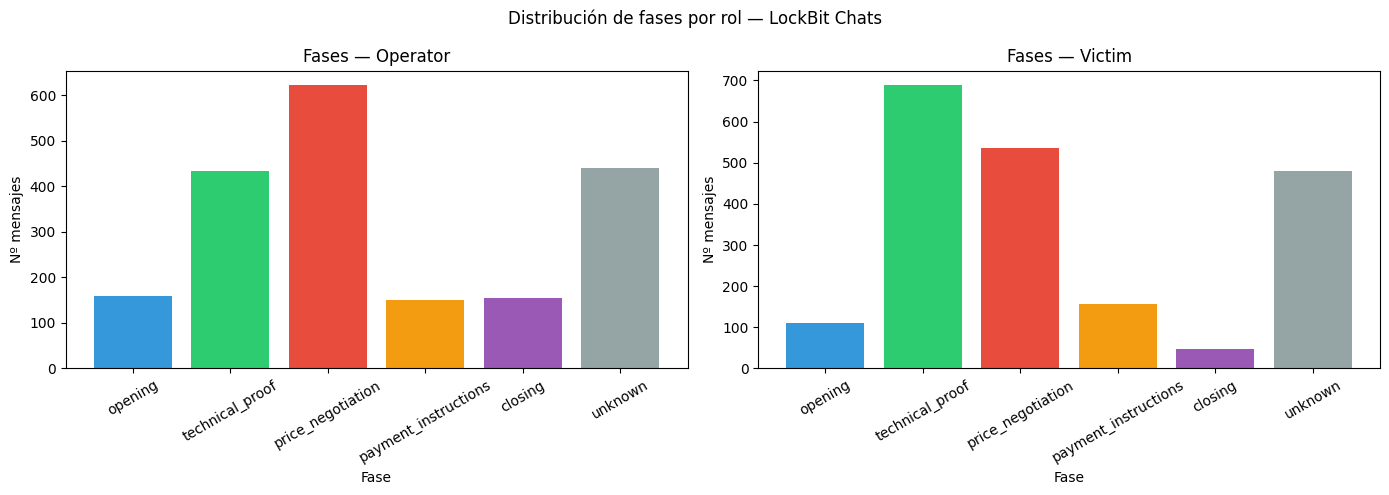

In [6]:
# Visualizamos la distribución de fases separando los mensajes de operadores y víctimas.
# Esto nos permite ver si ambos grupos participan en las mismas fases o si cada uno
# domina fases distintas (lo esperado: el operador da instrucciones, la víctima pregunta).

# Creamos la columna 'sender' a partir de la columna 'flag' para mayor claridad
classified['sender'] = classified['flag'].map({1: 'operator', 0: 'victim'})

# Dos gráficas de barras: una para el operador, otra para la víctima
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zip() combina las dos listas en pares: (axes[0], 'operator') y (axes[1], 'victim')
for ax, sender in zip(axes, ['operator', 'victim']):
    # Filtramos los mensajes de este remitente y contamos por fase
    sub = classified[classified.sender == sender]['phase'].value_counts()

    # Solo incluimos las fases que realmente tienen mensajes (para no dibujar barras vacías)
    phases_present = [p for p in phase_order if p in sub.index]

    # Obtenemos los valores y colores en el orden correcto de las fases
    vals = [sub.get(p, 0) for p in phases_present]
    colors = [phase_colors[p] for p in phases_present]

    # Dibujamos las barras con los colores de cada fase
    ax.bar(phases_present, vals, color=colors)
    ax.set_title(f'Fases — {sender.capitalize()}')
    ax.set_xlabel('Fase')
    ax.set_ylabel('Nº mensajes')

    # Rotamos las etiquetas del eje X 30 grados para que no se solapen
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de fases por rol — LockBit Chats')
plt.tight_layout()
plt.show()

In [7]:
# Mostramos un ejemplo completo de negociación clasificada mensaje a mensaje.
# Esto permite ver cómo las fases evolucionan a lo largo de la conversación,
# confirmando que la clasificación del LLM tiene sentido en el contexto real.

# Elegimos la víctima con más mensajes para tener la negociación más completa
# .groupby('clientid').size() cuenta mensajes por víctima
# .idxmax() devuelve el ID de la víctima con el máximo
top_victim = classified.groupby('clientid').size().idxmax()

# Filtramos todos los mensajes de esa víctima y los ordenamos cronológicamente
convo = classified[classified.clientid == top_victim].sort_values('created_at').reset_index(drop=True)

print(f'Negociación de ejemplo — víctima ID {top_victim} ({len(convo)} mensajes):')

# Mostramos cada mensaje con su hora, quién lo envió, la fase detectada y el contenido
for _, row in convo.iterrows():
    # → OPER = mensaje del operador (va hacia la víctima)
    # ← VÍCT = mensaje de la víctima (viene de la víctima)
    sender_label = '→ OPER' if row.flag == 1 else '← VÍCT'

    # Mostramos solo los primeros 80 caracteres para que quepa en una línea
    msg = str(row.content)[:80].replace('\n', ' ')

    # Formateamos la fecha como 'DD/MM HH:MM'; si no hay fecha, mostramos '??/??'
    dt = row.created_at.strftime('%d/%m %H:%M') if pd.notna(row.created_at) else '??/??'

    # :22s alinea el nombre de la fase en 22 caracteres para que todas las líneas estén alineadas
    print(f"  [{dt}] {sender_label} [{row.phase:22s}] {msg}")

Negociación de ejemplo — víctima ID 182 (430 mensajes):
  [02/03 04:27] ← VÍCT [technical_proof       ] You can attach a few files for test decryption by packing them into an archive w
  [02/03 04:35] ← VÍCT [opening               ] I want to  recover my files, please help 
  [02/03 05:14] ← VÍCT [opening               ] 02.03.2025 04:27:34 UTC Loshara  I want to recover my files, please help 
  [02/03 06:39] → OPER [opening               ] Hello
  [02/03 06:40] ← VÍCT [opening               ] hello
  [02/03 06:41] → OPER [price_negotiation     ] price of decrypt will be 90k$ in bitcoin
  [02/03 06:41] → OPER [unknown               ] your company market
  [02/03 06:43] ← VÍCT [unknown               ] please, give us us some kindly help, we are small business, not big company 
  [02/03 06:44] → OPER [technical_proof       ] and I saw your site which is not working now
  [02/03 06:45] ← VÍCT [price_negotiation     ] we are willing to solve the problem 
  [02/03 06:46] → OPER [technical_p

## 3. Métricas de negociación

In [8]:
# Calculamos estadísticas de cada negociación: cuántos mensajes hubo, cuánto duró
# y cuántas fases distintas se detectaron. Luego comparamos víctimas que pagaron vs no.

# .groupby('clientid').agg() agrupa por víctima y calcula varias métricas a la vez:
#   - n_msgs: número total de mensajes en la negociación
#   - first_msg: fecha del primer mensaje (inicio de la negociación)
#   - last_msg: fecha del último mensaje (fin de la negociación)
#   - n_phases: cuántas fases distintas hubo (variedad del proceso)
# .assign() añade columnas calculadas a partir de las existentes
# La duración se calcula restando fechas y convirtiendo a horas (segundos / 3600)
negotiation_stats = (classified.groupby('clientid').agg(
    n_msgs=('phase', 'count'),
    first_msg=('created_at', 'min'),
    last_msg=('created_at', 'max'),
    n_phases=('phase', 'nunique'),
).assign(duration_h=lambda df: (df.last_msg - df.first_msg).dt.total_seconds() / 3600)
.sort_values('n_msgs', ascending=False))

# Estadísticas generales de las negociaciones
print('=== ESTADÍSTICAS DE NEGOCIACIONES ===')
print(f'Víctimas con chat activo : {len(negotiation_stats)}')
print(f'Msgs por negociación     : mediana={negotiation_stats.n_msgs.median():.0f}, máx={negotiation_stats.n_msgs.max()}')
print(f'Duración (horas)         : mediana={negotiation_stats.duration_h.median():.1f}, máx={negotiation_stats.duration_h.max():.0f}')
print(f'Fases distintas/negoc    : mediana={negotiation_stats.n_phases.median():.1f}')

# Comparamos las negociaciones de las víctimas que pagaron vs las que no pagaron.
# paid_ids es el conjunto de IDs de víctimas que pagaron (paid_commission == 1)
paid_ids = set(clients[clients.paid_commission == 1].id)

# .isin() devuelve True para los IDs que están en el conjunto paid_ids
negotiation_stats['paid'] = negotiation_stats.index.isin(paid_ids)

print(f'\nVíctimas que pagaron con chat: {negotiation_stats.paid.sum()} de {len(negotiation_stats)}')
print('\nComparación pagadas vs no pagadas:')

# Agrupamos por si pagaron o no y calculamos la mediana de mensajes y duración.
# Esperamos que las víctimas que pagaron tuvieran negociaciones más largas.
print(negotiation_stats.groupby('paid')[['n_msgs','duration_h']].median().round(1).to_string())

=== ESTADÍSTICAS DE NEGOCIACIONES ===
Víctimas con chat activo : 208
Msgs por negociación     : mediana=4, máx=430
Duración (horas)         : mediana=8.2, máx=2962
Fases distintas/negoc    : mediana=2.0

Víctimas que pagaron con chat: 7 de 208

Comparación pagadas vs no pagadas:
       n_msgs  duration_h
paid                     
False     4.0         6.3
True    126.0       133.1


## 4. Perfilado de operadores

In [9]:
# Definimos el system prompt para el perfilado de operadores.
# Esta vez pedimos al LLM una respuesta más elaborada: un análisis del estilo
# de negociación del operador basado en sus mensajes. La respuesta debe estar
# en formato JSON para poder procesarla automáticamente.
PROFILE_SYSTEM = """You are a threat intelligence analyst studying LockBit ransomware operators.
Given a sample of messages sent by one LockBit operator to victims, infer their negotiation style and role.

Reply in JSON with these fields:
{
  "style": "<one of: aggressive, professional, patient, scripted, technical>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their approach and typical behavior>",
  "tactics": ["<up to 3 observed negotiation tactics>"]
}"""


def profile_operator(op_id, messages: list[str]) -> dict:
    """
    Genera un perfil psicológico y de estilo de negociación para un operador de LockBit,
    basándose en una muestra de sus mensajes.

    El LLM actúa aquí como un analista: lee los mensajes del operador y deduce
    su personalidad, tácticas y nivel de sofisticación. Es el mismo trabajo que
    haría un analista de inteligencia humano, pero automatizado.

    Parámetros:
        op_id: El ID numérico del operador en la base de datos
        messages (list[str]): Lista de mensajes enviados por este operador a sus víctimas

    Devuelve:
        dict: Un diccionario con los campos 'style', 'confidence', 'summary' y 'tactics'
              que describen el estilo de negociación del operador.
    """
    # Construimos un bloque de texto con los primeros 25 mensajes del operador.
    # Limitamos a 25 para no saturar la ventana de contexto del modelo.
    # Limitamos cada mensaje a 200 caracteres para equilibrar detalle y coste.
    # Cada mensaje va precedido de '- ' para formato de lista.
    msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:25])

    try:
        # Enviamos los mensajes al LLM pidiéndole que genere el perfil
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': PROFILE_SYSTEM},
                {'role': 'user', 'content': f'Operator ID: {op_id}\n\nMessages:\n{msg_block}'}
            ],
            # temperature=0.1 permite una ligera variación creativa (vs 0 para clasificación pura)
            # num_predict=300 da espacio suficiente para el JSON con el perfil completo
            options={'temperature': 0.1, 'num_predict': 300}
        )
        # Extraemos el texto de la respuesta
        raw = resp.message.content.strip()

        # Localizamos el bloque JSON en la respuesta (el LLM puede añadir texto antes/después)
        # .find('{') devuelve la posición del primer '{'
        # .rfind('}') devuelve la posición del último '}'
        # + 1 incluye el carácter '}' en el slice
        start, end = raw.find('{'), raw.rfind('}') + 1

        # json.loads() convierte el texto JSON al diccionario Python correspondiente
        return json.loads(raw[start:end])
    except Exception as e:
        # Si hay un error (JSON inválido, modelo no disponible, etc.), devolvemos un perfil vacío
        return {'style': 'unknown', 'confidence': 'low', 'summary': str(e), 'tactics': []}


# Filtramos solo los mensajes enviados por operadores (flag == 1)
# para no contaminar el perfil con los mensajes de las víctimas
op_classified = classified[classified.flag == 1]

# Seleccionamos solo los operadores con al menos 5 mensajes para tener suficiente información
# .size() cuenta cuántos mensajes tiene cada operador
# [active_ops >= 5] filtra los operadores con 5 o más mensajes
# .index.tolist() convierte el índice a lista de Python
active_ops = op_classified.groupby('advid').size()
active_ops = active_ops[active_ops >= 5].index.tolist()
print(f'Operadores a perfilar (≥5 mensajes): {len(active_ops)}')

Operadores a perfilar (≥5 mensajes): 20


In [10]:
# Diccionario donde guardaremos el perfil de cada operador.
# La clave será el ID numérico del operador y el valor será el diccionario con su perfil.
operator_profiles = {}

# Recorremos cada operador activo y generamos su perfil con el LLM.
# tqdm() muestra una barra de progreso para saber cuánto falta.
for op_id in tqdm(active_ops, desc='Perfilando operadores'):
    # Obtenemos todos los mensajes que este operador envió a sus víctimas
    msgs = op_classified[op_classified.advid == op_id]['content'].tolist()

    # Llamamos a la función de perfilado y guardamos el resultado.
    # int(op_id) convierte el ID a entero normal por si es numpy int64
    operator_profiles[int(op_id)] = profile_operator(op_id, msgs)

# Mostramos un resumen de los perfiles generados
print('\n=== PERFILES DE OPERADORES ===')
for op_id, profile in operator_profiles.items():
    # Buscamos el nombre de usuario correspondiente a este ID numérico
    # users[users.id == op_id]['login'].values devuelve un array con el login del usuario
    login = users[users.id == op_id]['login'].values

    # Si encontramos el nombre, lo usamos; si no, usamos 'ID_xxx' como identificador
    login_str = login[0] if len(login) > 0 else f'ID_{op_id}'

    # Mostramos el nombre del operador, su estilo detectado y el nivel de confianza
    print(f'  {login_str:<20} [{profile.get("style","?"):12s}] ({profile.get("confidence","?")})')

    # Mostramos el resumen, limitado a 100 caracteres para no saturar la pantalla
    print(f'     {profile.get("summary","")[:100]}')

Perfilando operadores:   0%|          | 0/20 [00:00<?, ?it/s]

Perfilando operadores:   5%|▌         | 1/20 [00:02<00:47,  2.50s/it]

Perfilando operadores:  10%|█         | 2/20 [00:04<00:41,  2.33s/it]

Perfilando operadores:  15%|█▌        | 3/20 [00:06<00:36,  2.15s/it]

Perfilando operadores:  20%|██        | 4/20 [00:08<00:34,  2.19s/it]

...

Perfilando operadores:  90%|█████████ | 18/20 [00:41<00:04,  2.40s/it]

Perfilando operadores:  95%|█████████▌| 19/20 [00:44<00:02,  2.36s/it]

Perfilando operadores: 100%|██████████| 20/20 [00:46<00:00,  2.34s/it]

Perfilando operadores: 100%|██████████| 20/20 [00:46<00:00,  2.32s/it]


=== PERFILES DE OPERADORES ===
  Brown                [scripted    ] (high)
     The LockBit operator follows a structured and repetitive negotiation style. They are patient and met
  PiotrBond            [aggressive  ] (medium)
     The LockBit operator demonstrates an aggressive negotiation style, repeatedly urging the victim to p
  ArrynBaird           [aggressive  ] (high)
     The LockBit operator exhibits an aggressive negotiation style, demanding immediate payment and threa
  Anon666              [aggressive  ] (high)
     The LockBit operator exhibits an aggressive negotiation style, repeatedly demanding payment and thre
  GlenOrtega           [aggressive  ] (medium)
     The LockBit operator exhibits an aggressive negotiation style, setting a high ransom demand and refu
  jhon0722             [aggressive  ] (high)
     The LockBit operator with ID 18 exhibits an aggressive negotiation style, immediately pressing for h
  Christopher          [aggressive  ] (high)
     The Lock

## 5. Guardar resultados

In [11]:
# Guardamos los mensajes clasificados en formato parquet para usarlos en notebooks siguientes.
# index=False evita guardar el índice numérico como columna extra.
classified.to_parquet(CHATS_OUT, index=False)

# Antes de guardar los perfiles, enriquecemos el diccionario reemplazando los IDs numéricos
# por los nombres de usuario (más legibles para análisis posteriores).
profiles_with_names = {}
for op_id, profile in operator_profiles.items():
    # Buscamos el nombre de usuario de este operador
    login = users[users.id == op_id]['login'].values
    name = login[0] if len(login) > 0 else f'ID_{op_id}'
    profiles_with_names[name] = profile

# Guardamos los perfiles en formato JSON (texto estructurado que cualquier programa puede leer).
# json.dump() escribe el diccionario al archivo.
# indent=2 formatea el JSON con sangrías para que sea legible por humanos.
# ensure_ascii=False permite que se guarden caracteres especiales sin codificarlos.
with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
    json.dump(profiles_with_names, f, indent=2, ensure_ascii=False)

# Eliminamos el archivo de checkpoint porque ya hemos terminado correctamente.
# .unlink() borra un archivo; lo hacemos solo si el checkpoint existe.
if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()

# Confirmamos qué archivos se crearon y cuántos datos contienen
print(f'Mensajes clasificados → {CHATS_OUT}')
print(f'Perfiles de operadores → {PROFILES_OUT}')
print(f'\nResumen: {len(classified):,} msgs | {len(operator_profiles)} operadores perfilados')

Mensajes clasificados → data/processed/chats_classified.parquet
Perfiles de operadores → data/processed/operator_profiles.json

Resumen: 3,977 msgs | 20 operadores perfilados
